In [139]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [140]:
df = pd.DataFrame()

In [169]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [0,1,1,0,0,1,0,1,0,1]

<Axes: xlabel='X1', ylabel='X2'>

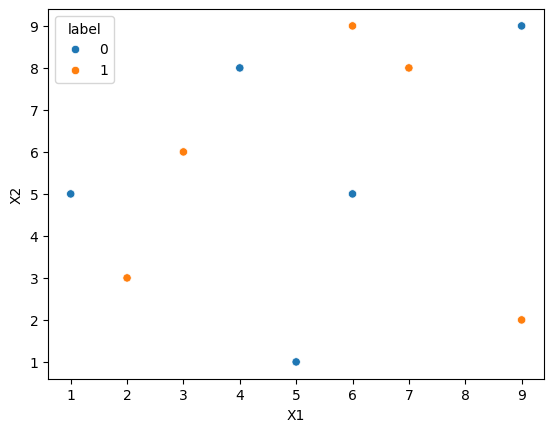

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=df['X1'],
    y=df['X2'],
    hue=df['label'])

In [171]:
df['weights'] = 1 / df.shape[0]
df

,X1,X2,label,weights
0,1,5,0,0.1
1,2,3,1,0.1
2,3,6,1,0.1
3,4,8,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,1,0.1


In [172]:
from sklearn.tree import DecisionTreeClassifier

In [173]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-2].values

In [174]:
dt = DecisionTreeClassifier(max_depth=1)

In [175]:
dt.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

<Axes: >

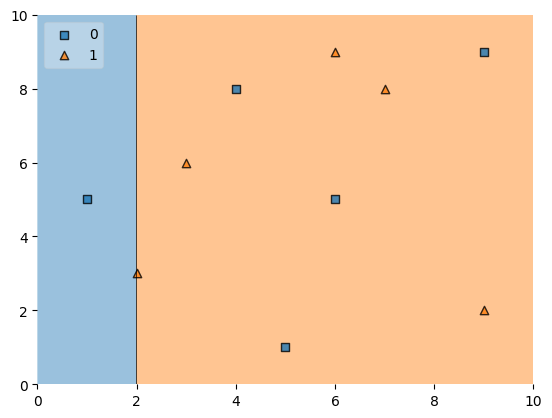

In [176]:
plot_decision_regions(X,y,clf=dt,legend=2)

[Text(0.5, 0.75, 'x[0] <= 1.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.494\nsamples = 9\nvalue = [4, 5]'),
 Text(0.625, 0.5, '  False')]

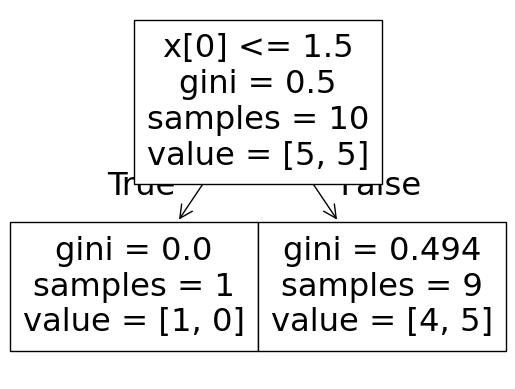

In [177]:
from sklearn.tree import plot_tree
plot_tree(dt)

In [178]:
y_pred =  dt.predict(X)

In [179]:
df['y_pred'] = y_pred
df

,X1,X2,label,weights,y_pred
0,1,5,0,0.1,0
1,2,3,1,0.1,1
2,3,6,1,0.1,1
3,4,8,0,0.1,1
4,5,1,0,0.1,1
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,1,0.1,1


In [125]:
def calculate_model_weight(error):
    return 0.5*(np.log((1-error)/(error+0.0000001)))

In [180]:
alpha1 = calculate_model_weight(0.4)
alpha1

np.float64(0.20273242905409775)

In [181]:
def update_row_weights(row,alpha=0.423):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [182]:
df['update_weights'] = df.apply(update_row_weights,axis=1)

In [183]:
df

,X1,X2,label,weights,y_pred,update_weights
0,1,5,0,0.1,0,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,1,0.1,1,0.065508
3,4,8,0,0.1,1,0.152653
4,5,1,0,0.1,1,0.152653
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,1,0.1,1,0.065508


In [184]:
df['nomalized_weights'] = df['update_weights'] / df['update_weights'].sum()
df

,X1,X2,label,weights,y_pred,update_weights,nomalized_weights
0,1,5,0,0.1,0,0.065508,0.065269
1,2,3,1,0.1,1,0.065508,0.065269
2,3,6,1,0.1,1,0.065508,0.065269
3,4,8,0,0.1,1,0.152653,0.152097
4,5,1,0,0.1,1,0.152653,0.152097
5,6,9,1,0.1,1,0.065508,0.065269
6,6,5,0,0.1,1,0.152653,0.152097
7,7,8,1,0.1,1,0.065508,0.065269
8,9,9,0,0.1,1,0.152653,0.152097
9,9,2,1,0.1,1,0.065508,0.065269


In [185]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [186]:
df

,X1,X2,label,weights,y_pred,update_weights,nomalized_weights,cumsum_upper,cumsum_lower
0,1,5,0,0.1,0,0.065508,0.065269,0.065269,0.000000
1,2,3,1,0.1,1,0.065508,0.065269,0.130538,0.065269
2,3,6,1,0.1,1,0.065508,0.065269,0.195807,0.130538
3,4,8,0,0.1,1,0.152653,0.152097,0.347903,0.195807
4,5,1,0,0.1,1,0.152653,0.152097,0.500000,0.347903
5,6,9,1,0.1,1,0.065508,0.065269,0.565269,0.500000
6,6,5,0,0.1,1,0.152653,0.152097,0.717366,0.565269
7,7,8,1,0.1,1,0.065508,0.065269,0.782634,0.717366
8,9,9,0,0.1,1,0.152653,0.152097,0.934731,0.782634
9,9,2,1,0.1,1,0.065508,0.065269,1.000000,0.934731


In [187]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [188]:
index_values = create_new_dataset(df)

index_values

[5, 9, 6, 6, 6, 6, 3, 4, 9, 4]

In [189]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [190]:
second_df

,X1,X2,label,weights
5,6,9,1,0.1
9,9,2,1,0.1
6,6,5,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
3,4,8,0,0.1
4,5,1,0,0.1
9,9,2,1,0.1
4,5,1,0,0.1


In [191]:
dt1 = DecisionTreeClassifier()

In [192]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
dt1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

<Axes: >

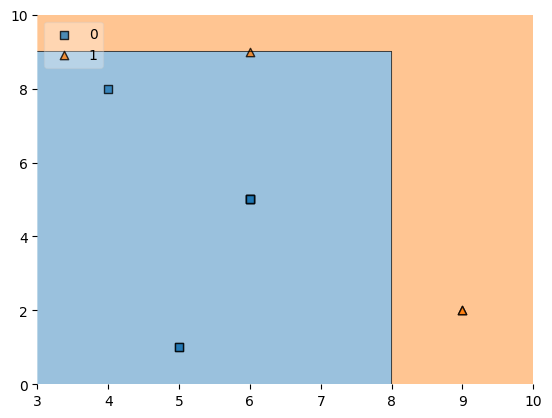

In [193]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [194]:
second_df['y_pred'] = dt1.predict(X)
second_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
9,9,2,1,0.1,1
6,6,5,0,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0
3,4,8,0,0.1,0
4,5,1,0,0.1,0
9,9,2,1,0.1,1
4,5,1,0,0.1,0


In [195]:
alpha2 = calculate_model_weight(0)
alpha2

np.float64(8.05904782547916)

In [197]:
query = np.array([1,5]).reshape(1,2)
dt.predict(query)

array([0])

In [198]:
dt1.predict(query)

array([0])

In [199]:
alpha1*0 + alpha2*0

np.float64(0.0)

In [200]:
np.sign(0)

np.int64(0)

In [205]:
query2 = np.array([9,2]).reshape(1,2)
dt.predict(query2)

array([1])

In [206]:
dt1.predict(query2)

array([1])

In [207]:
alpha1*1 + alpha2*1

np.float64(8.261780254533258)

In [208]:
np.sign(8.261)

np.float64(1.0)